In [24]:
import tensorflow as tf

In [25]:
import numpy as np

In [26]:
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session

In [27]:
#import mnist dataset
from tensorflow.keras.datasets import mnist

In [28]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [30]:
len(np.unique(y_train))

10

In [31]:
#prepocessing data

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2]).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2]).astype('float32') / 255

In [ ]:
#define feed-forward neural network model

def create_model(input_features_number, classes_number):
    """
    Create a simple feedforward neural network model.
    
    Args:
        input_features_number (int): Number of input features.
    
    Returns:
        model (tf.keras.Model): Compiled Keras model.
    """

    # Defining layers
    model = Sequential([
        InputLayer(shape=(input_features_number,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'), # relu for hidden layers
        Dense(classes_number, activation='softmax') # for distribution probabilities
    ])

    # Defining charateristics

    return model

In [33]:
clear_session()
model = create_model(X_train.shape[1], len(np.unique(y_train))) # Example for MNIST dataset (28x28 images flattened to 784)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
hist = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=5,
    verbose=1
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8802 - loss: 0.4217
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9653 - loss: 0.1133
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9771 - loss: 0.0786
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9817 - loss: 0.0637
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0464


In [36]:
eval_test = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test loss: {eval_test[0]}")
print(f"Test accuracy: {eval_test[1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9734 - loss: 0.1007
Test loss: 0.08546492457389832
Test accuracy: 0.9768999814987183


In [44]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.97      0.99      0.98      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

[[ 971    0    1    1    0    0    3    1    3    0]
 [   0 1129    2    0    0    1    2    0    1    0]
 [   3    6 1006    3    2    0    2    4    6    0]
 [   0    0    5  988    0    5    0    4    4    4]
 [   1    3    3    2  964   

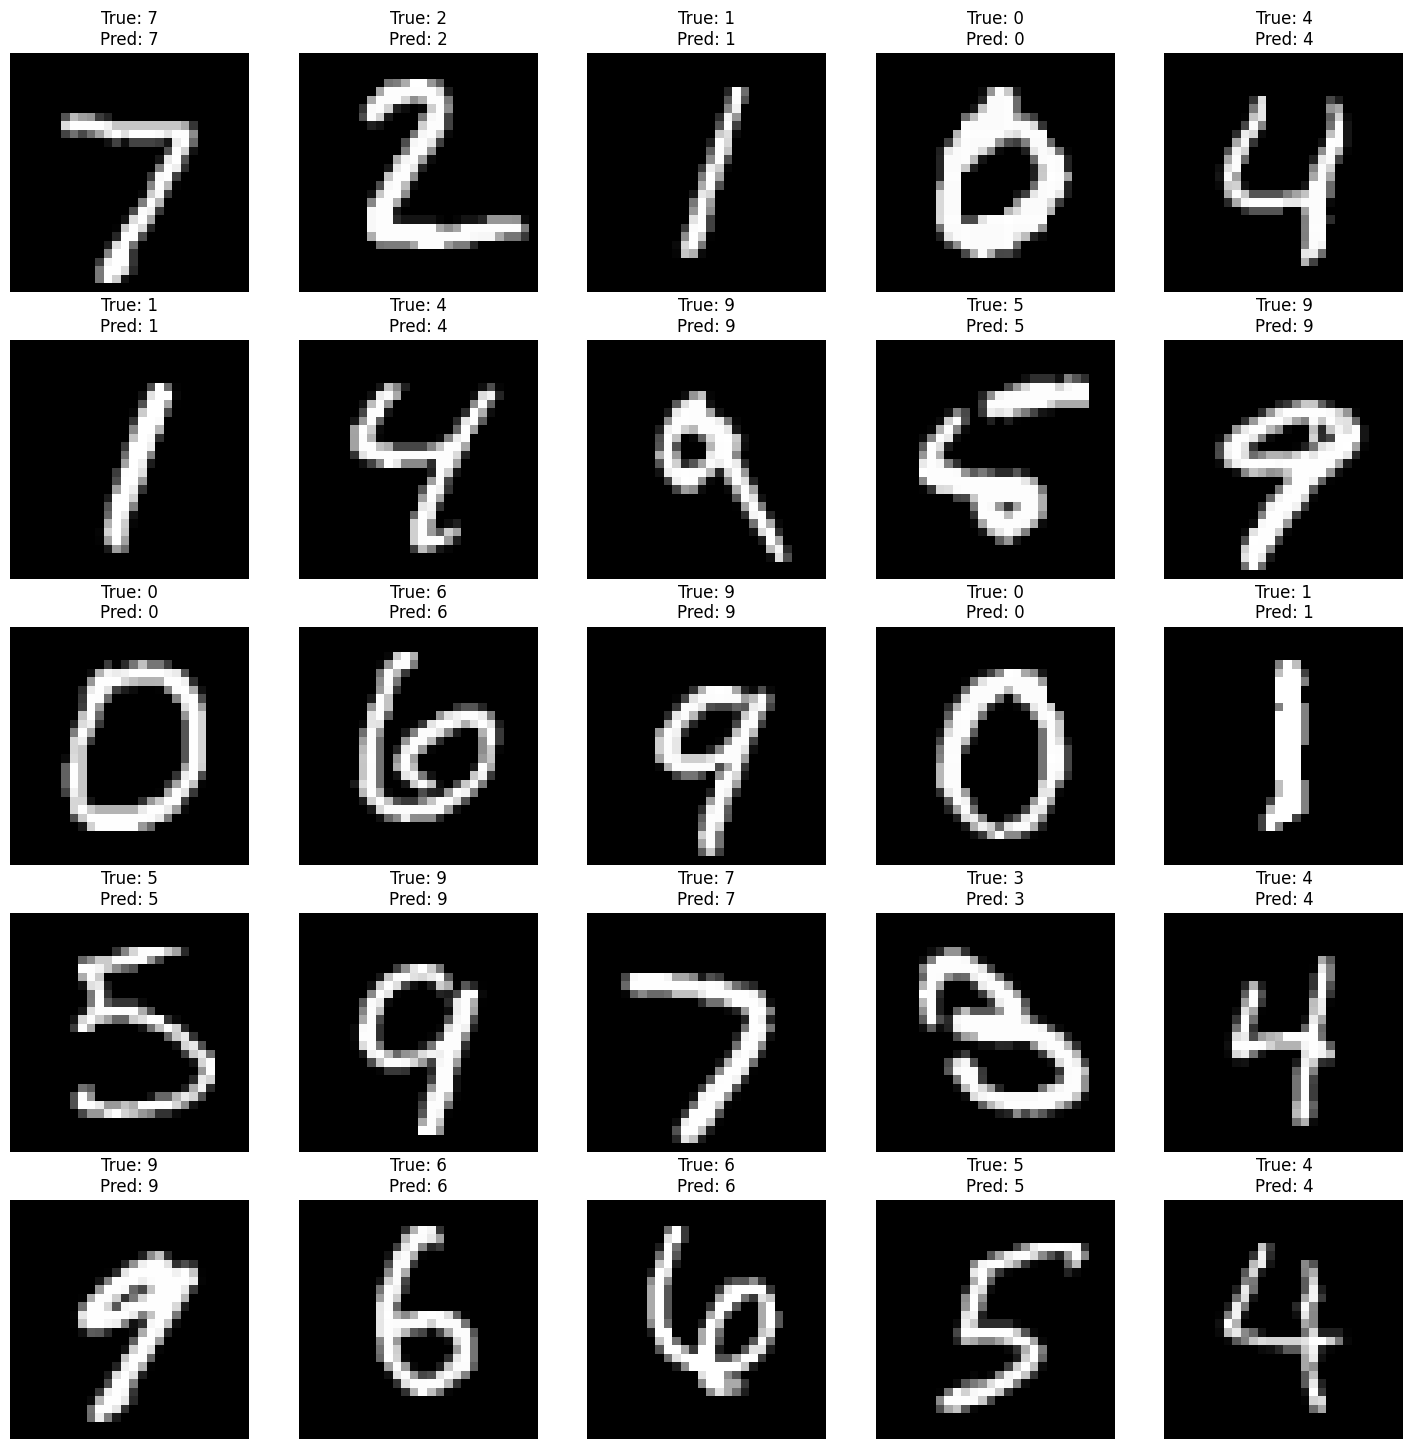

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

#show pictures

def show_images(images, labels, predictions=None):
    """
    Show images with their labels and predictions.
    
    Args:
        images (np.ndarray): Array of images to display.
        labels (np.ndarray): Array of true labels.
        predictions (np.ndarray, optional): Array of predicted labels. Defaults to None.
    """
    
    plt.figure(figsize=(18, 18))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"True: {labels[i]}\nPred: {predictions[i]}" if predictions is not None else f"True: {labels[i]}")
    plt.show()

show_images(X_test, y_test, y_pred)